# Insurance Reviews NLP: rating prediction, topics and semantic search

Supervised and unsupervised NLP on ~24,000 French insurance customer reviews: cleaning, spelling correction,
translation to English, TF-IDF baseline with SHAP, LDA topic modeling, sentence embeddings with a PyTorch
classifier, Word2Vec, and cosine-similarity semantic search. The results feed the Streamlit app in `app/`.

> **About the outputs.** This notebook was run on Google Colab (T4 GPU) in March 2026. The outputs shown are
> from that run. For publication, comments and log messages were translated to English, progress bars and
> install logs were removed, and review excerpts printed in the outputs were replaced by a marker, since
> reviews can contain personal information. Plot labels are still in French, as in the original figures.

In [ ]:
from pathlib import Path

# On Google Colab, mount your Drive first and point DATA_DIR to your copy of the data:
#   from google.colab import drive; drive.mount('/content/drive')
#   DATA_DIR = Path('/content/drive/MyDrive/insurance-reviews-nlp/data')
DATA_DIR = Path('../data')
RAW_DIR = DATA_DIR / 'raw'              # avis_*_traduit*.xlsx files provided by the course
PROCESSED_DIR = DATA_DIR / 'processed'  # outputs reused by the Streamlit app
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 0. Setup
Dependencies for translation, deep learning, visualisation and the app are listed in `requirements.txt`.

In [ ]:
# %pip install -r ../requirements.txt

## 1. Data Exploration & Pipeline
**Objective:** Analyze the distribution of our dataset containing 24,000 insurance reviews (rating distribution, frequent N-grams, WordCloud).

**Data Cleaning & Translation:** To maximize the performance of our Deep Learning models, we implemented a highly optimized pipeline:
- **Regex cleaning**: Noise and special character removal.
- **Spelling correction (`pyspellchecker`)**: We optimized this step using a custom dictionary cache to drastically reduce computation time.
- **Full English Translation (`deep-translator`)**: We used **Multi-Threading** (15 concurrent workers) to translate the entire corpus to English. This is a crucial technical choice to ensure compatibility and maximum accuracy with Hugging Face pre-trained models.

In [ ]:
import pandas as pd
import glob

print("Loading review files...")
all_files = glob.glob(str(RAW_DIR / 'avis_*_traduit*.xlsx'))

df_list = []
for file in all_files:
    try:
        df_temp = pd.read_excel(file)
        df_list.append(df_temp)
    except:
        df_temp = pd.read_csv(file, encoding='latin-1', on_bad_lines='skip', engine='python')
        df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

# Clean column names, drop empty and duplicate reviews
df.columns = df.columns.str.strip().str.replace('\ufeff', '').str.replace('ï»¿', '')
df = df.dropna(subset=['avis', 'note'])
df = df.drop_duplicates(subset=['avis'])

print(f"--> Total reviews ready for modelling: {df.shape[0]}")

Loading review files...
--> Total reviews ready for modelling: 24069


### Spelling correction and translation

In [ ]:
from spellchecker import SpellChecker
from deep_translator import GoogleTranslator
from tqdm.notebook import tqdm
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
import re

tqdm.pandas()
spell = SpellChecker(language='fr')
mot_cache = {} # global cache of corrections already computed

# 1. Cleaning: lowercase, keep letters (incl. French accents), digits and spaces
def clean_text_fr(text):
    if pd.isna(text): return ""
    text = re.sub(r'[^\w\sàâäéèêëïîôöùûüç]', ' ', str(text).lower())
    return " ".join(text.split())

# 2. Spelling correction
def corriger_fautes_ultime(texte):
    if not texte: return ""
    words = texte.split()

    # find the misspelled words in one call
    misspelled = spell.unknown(words)
    corrected_list = []

    for w in words:
        if w in misspelled:
            # reuse the correction if this word was already corrected
            if w not in mot_cache:
                suggestion = spell.correction(w)
                mot_cache[w] = suggestion if suggestion is not None else w
            corrected_list.append(mot_cache[w])
        else:
            # the word is correct, keep it
            corrected_list.append(w)

    return " ".join(corrected_list)

# 3. Translation (Google Translate through deep-translator)
def traduire_texte(texte):
    if not isinstance(texte, str) or texte.strip() == "": return ""
    try:
        return GoogleTranslator(source='fr', target='en').translate(texte[:4000])
    except:
        return texte

# ================= RUN =================

print("Step A: character cleaning...")
df['avis_cor'] = df['avis'].progress_apply(clean_text_fr)

print("\nStep B: spelling correction (cache + unknown words)...")
df['avis_cor'] = df['avis_cor'].progress_apply(corriger_fautes_ultime)

print("\nStep C: multi-threaded translation (15 concurrent requests)...")


textes_a_traduire = df['avis'].tolist()

with ThreadPoolExecutor(max_workers=15) as executor:
    traductions = list(tqdm(executor.map(traduire_texte, textes_a_traduire), total=len(textes_a_traduire)))

df['avis_cor_en'] = traductions

# Save the cleaned dataset (reused by the Streamlit app)
df.to_csv(PROCESSED_DIR / 'reviews_clean.csv', index=False)
print("\n✅ Done and saved!")

Step A: character cleaning...



Step B: spelling correction (cache + unknown words)...



Step C: multi-threaded translation (15 concurrent requests)...



✅ Done and saved!


--- EXPLORATORY DATA ANALYSIS ---


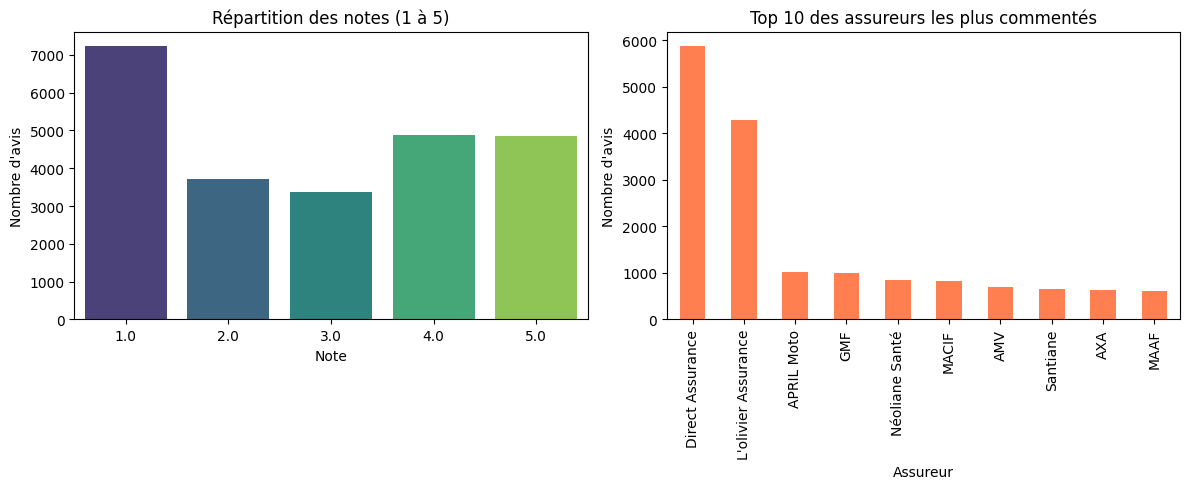

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EXPLORATORY DATA ANALYSIS ---")
plt.figure(figsize=(12, 5))

# Chart 1: rating distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='note', palette='viridis')
plt.title('Répartition des notes (1 à 5)')
plt.xlabel('Note')
plt.ylabel('Nombre d\'avis')

# Chart 2: most reviewed insurers
plt.subplot(1, 2, 2)
df['assureur'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 des assureurs les plus commentés')
plt.xlabel('Assureur')
plt.ylabel('Nombre d\'avis')

plt.tight_layout()
plt.show()

--- MOST FREQUENT WORDS ---


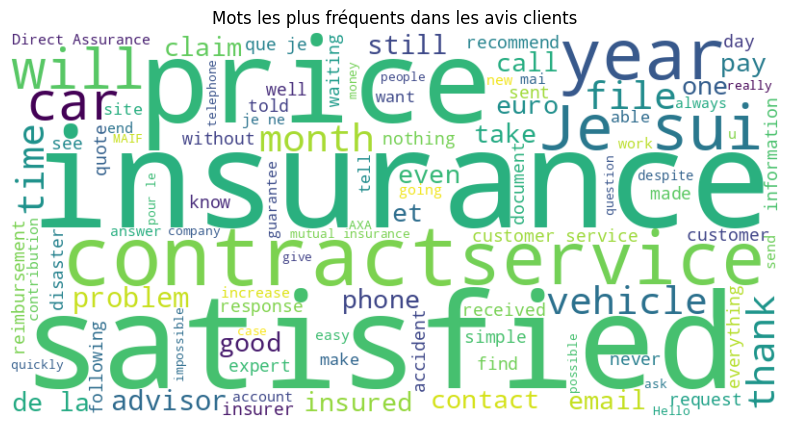

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("--- MOST FREQUENT WORDS ---")
# Word cloud of the translated English reviews
text_for_wc = " ".join(df['avis_cor_en'].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_for_wc)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mots les plus fréquents dans les avis clients')
plt.show()

## 2. Supervised Learning: TF-IDF & Classical ML (Baseline)
**Approach:** Before using complex neural networks, we establish a strong baseline.
- **Model:** Logistic Regression trained on TF-IDF vectors (with English stop-words filtered out).
- **Explainability (SHAP):** We use `LinearExplainer` to interpret the model. The SHAP summary plot highlights which specific English words have the strongest influence on predicting the 1-to-5 star ratings.

--- 2. Supervised learning: TF-IDF + logistic regression ---
TF-IDF vectorisation (English stop words removed)...
Training the logistic regression...

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         1.0       0.62      0.85      0.71      1463
         2.0       0.35      0.21      0.26       700
         3.0       0.37      0.16      0.23       695
         4.0       0.42      0.43      0.42       990
         5.0       0.52      0.58      0.55       966

    accuracy                           0.52      4814
   macro avg       0.46      0.45      0.43      4814
weighted avg       0.48      0.52      0.49      4814


--- EXPLAINING PREDICTIONS (SHAP) ---
English words with the strongest influence on the prediction:


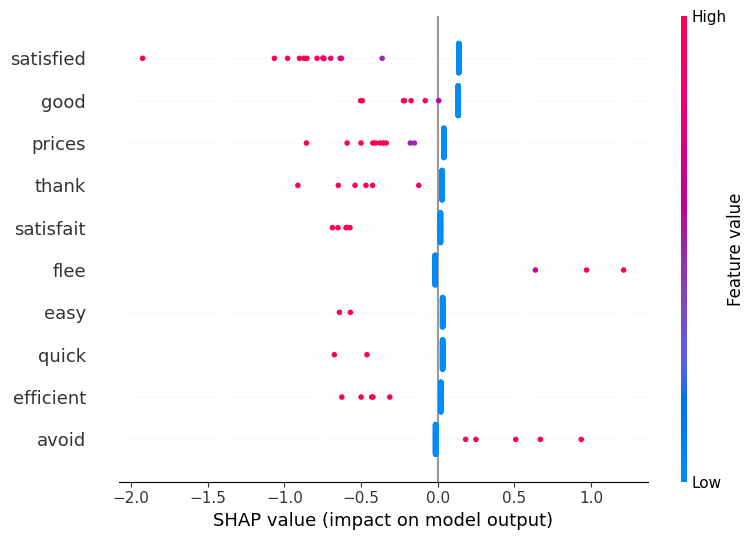

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import shap
import numpy as np

print("--- 2. Supervised learning: TF-IDF + logistic regression ---")

# 1. No missing values in the English column
X = df['avis_cor_en'].fillna("")
y = df['note']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("TF-IDF vectorisation (English stop words removed)...")
# 2. Stop words are filtered out to avoid useless bias
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training the logistic regression...")
model_tfidf = LogisticRegression(max_iter=1000, n_jobs=-1)
model_tfidf.fit(X_train_tfidf, y_train)

# 3. Evaluation
y_pred = model_tfidf.predict(X_test_tfidf)
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# 4. SHAP explanation
print("\n--- EXPLAINING PREDICTIONS (SHAP) ---")
# A background sample keeps the computation fast
echantillon = shap.sample(X_train_tfidf, 100)
explainer = shap.LinearExplainer(model_tfidf, echantillon, feature_perturbation="interventional")

# 100 test reviews for the plot
choix_avis = X_test_tfidf[:100]
choix_avis_dense = choix_avis.toarray() if hasattr(choix_avis, "toarray") else choix_avis

shap_values = explainer.shap_values(choix_avis_dense)

# Handle the different shapes returned by SHAP versions
if isinstance(shap_values, list):
    valeurs_a_afficher = shap_values[0]
elif len(np.array(shap_values).shape) == 3:
    valeurs_a_afficher = shap_values[:, :, 0]
else:
    valeurs_a_afficher = shap_values

mots = vectorizer.get_feature_names_out()
print("English words with the strongest influence on the prediction:")
shap.summary_plot(valeurs_a_afficher, choix_avis_dense, feature_names=mots, max_display=10)

## 3. Classical Models with Themes (Topic Modeling)
**Approach:** To meet the requirement of detecting subjects/categories (like Pricing, Customer Service, etc.) without manual labeling, we use an Unsupervised Learning technique.
- **Model:** Latent Dirichlet Allocation (LDA).
- We extract the **top 5 underlying themes** discussed by customers and display their most representative keywords to automatically categorize the reviews.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

print("--- 3. Topic modeling (LDA) ---")

# 1. Dedicated TF-IDF vectorisation for LDA
vectorizer_lda = TfidfVectorizer(max_features=1000, stop_words='english')
X_lda = vectorizer_lda.fit_transform(df['avis_cor_en'].fillna(""))

# 2. Train the LDA model (5 topics)
print("Looking for the 5 main topics in the reviews...")
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_lda)

# 3. Keywords of each topic
print("\nTopics (English keywords):")
mots_lda = vectorizer_lda.get_feature_names_out()

for index, topic in enumerate(lda.components_):
    # 10 most representative words
    top_mots = [mots_lda[i] for i in topic.argsort()[-10:]]
    print(f"👉 Topic {index + 1}: {', '.join(top_mots)}")

--- 3. Topic modeling (LDA) ---
Looking for the 5 main topics in the reviews...

Topics (English keywords):
👉 Topic 1: fast, simple, thank, recommend, insurance, good, prices, service, price, satisfied
👉 Topic 2: que, est, pas, en, pour, les, la, le, je, et
👉 Topic 3: carte, action, non, fuir, 19, client, cost, allianz, works, low
👉 Topic 4: customer, processing, ag2r, pension, flee, disability, deplorable, cardif, files, zero
👉 Topic 5: don, vehicle, pay, customer, mutual, months, year, contract, years, insurance


## 4. Supervised Learning: Pre-trained Embeddings & Deep Learning
**Comparison of Different Models:** The classical TF-IDF model lacks semantic understanding. We now upgrade to deep learning.
- **Embeddings:** We use Hugging Face's `paraphrase-multilingual-MiniLM-L12-v2` (`Sentence-Transformers`) to convert reviews into dense contextual vectors.
- **Custom Neural Network:** We built and trained a custom PyTorch Neural Network (Linear layers, ReLU, Dropout) over 10 epochs.
- **Result:** A small but consistent gain over the TF-IDF baseline on the exact 1-to-5 star rating (accuracy 0.52 → 0.54, macro F1 0.43 → 0.46). Middle ratings (2 and 3 stars) stay hard for both models. The embeddings of the whole corpus are saved for the Streamlit application.

--- 4. Pre-trained embeddings + neural network ---
Device: CUDA
Step 1: loading the Hugging Face model...


Step 2: encoding the English reviews...



Step 3: building the PyTorch network...

Step 4: training (10 epochs)...
Epoch 1/10 done - loss: 1.1365
Epoch 2/10 done - loss: 1.0654
Epoch 3/10 done - loss: 1.0475
Epoch 4/10 done - loss: 1.0307
Epoch 5/10 done - loss: 1.0147
Epoch 6/10 done - loss: 1.0020
Epoch 7/10 done - loss: 0.9844
Epoch 8/10 done - loss: 0.9659
Epoch 9/10 done - loss: 0.9501
Epoch 10/10 done - loss: 0.9348

Step 5: evaluation...

--- CLASSIFICATION REPORT (DEEP LEARNING) ---
              precision    recall  f1-score   support



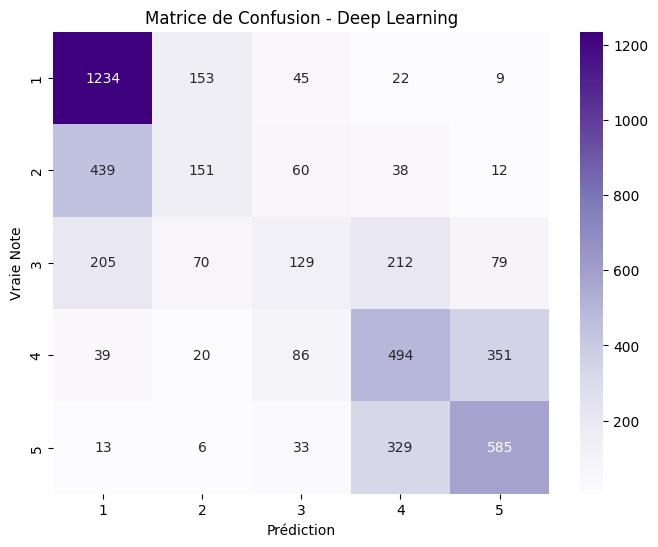


Step 6: saving the embeddings of the whole corpus for the Streamlit app...


✅ Embeddings saved!

--- 2D PROJECTION OF THE EMBEDDINGS (PCA) ---


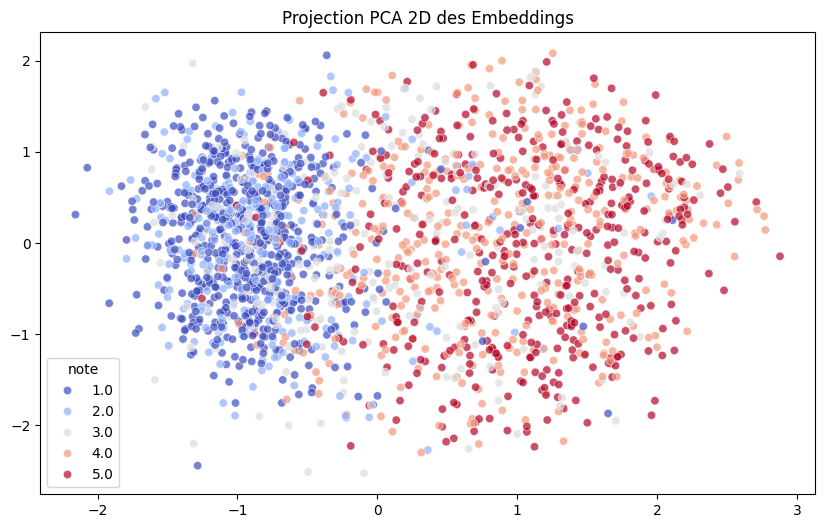

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import pickle

print("--- 4. Pre-trained embeddings + neural network ---")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device.upper()}")

print("Step 1: loading the Hugging Face model...")
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2').to(device)

print("Step 2: encoding the English reviews...")
# X_train and X_test contain 'avis_cor_en' (see the TF-IDF cell)
X_train_emb = embedder.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = embedder.encode(X_test.tolist(), show_progress_bar=True)

# PyTorch tensors (ratings shifted from 1-5 to 0-4)
y_train_tensor = torch.tensor(y_train.values - 1, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values - 1, dtype=torch.long)
X_train_tensor = torch.tensor(X_train_emb, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_emb, dtype=torch.float32)

dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print("\nStep 3: building the PyTorch network...")
class TextClassifier(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 5) # 5 outputs (one per star rating)
        )

    def forward(self, x):
        return self.network(x)

model_dl = TextClassifier(X_train_emb.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dl.parameters(), lr=0.001)

print("\nStep 4: training (10 epochs)...")
for epoch in range(10):
    model_dl.train()
    total_loss = 0
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        predictions = model_dl(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 done - loss: {total_loss/len(dataloader):.4f}")

print("\nStep 5: evaluation...")
model_dl.eval()
with torch.no_grad():
    outputs = model_dl(X_test_tensor.to(device))
    _, predicted = torch.max(outputs.data, 1)

y_pred_dl = predicted.cpu().numpy() + 1
y_test_actual = y_test_tensor.numpy() + 1

print("\n--- CLASSIFICATION REPORT (DEEP LEARNING) ---")
print(classification_report(y_test_actual, y_pred_dl))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_actual, y_pred_dl), annot=True, fmt='d', cmap='Purples',
            xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
plt.title('Matrice de Confusion - Deep Learning')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Note')
plt.show()

print("\nStep 6: saving the embeddings of the whole corpus for the Streamlit app...")
# The whole dataset is encoded for the app's semantic search (RAG)
tous_les_textes = df['avis_cor_en'].fillna("").tolist()
tous_les_embeddings = embedder.encode(tous_les_textes, show_progress_bar=True)

with open(PROCESSED_DIR / 'review_embeddings.pkl', 'wb') as f:
    pickle.dump(tous_les_embeddings, f)
print("✅ Embeddings saved!")

print("\n--- 2D PROJECTION OF THE EMBEDDINGS (PCA) ---")
pca = PCA(n_components=2)
echantillon_taille = min(2000, len(tous_les_embeddings))
embeddings_2d = pca.fit_transform(tous_les_embeddings[:echantillon_taille])
notes_echantillon = df['note'].iloc[:echantillon_taille]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=notes_echantillon, palette='coolwarm', alpha=0.7)
plt.title("Projection PCA 2D des Embeddings")
plt.show()

--- 4b. Cosine similarity between two reviews ---
Review 1: [review text omitted: personal data]
Review 2: [review text omitted: personal data]
-> Cosine similarity between the two reviews: 0.3610 (closer to 1 = closer meaning)

--- 4c. 2D visualisation of the embeddings (Matplotlib + PCA) ---


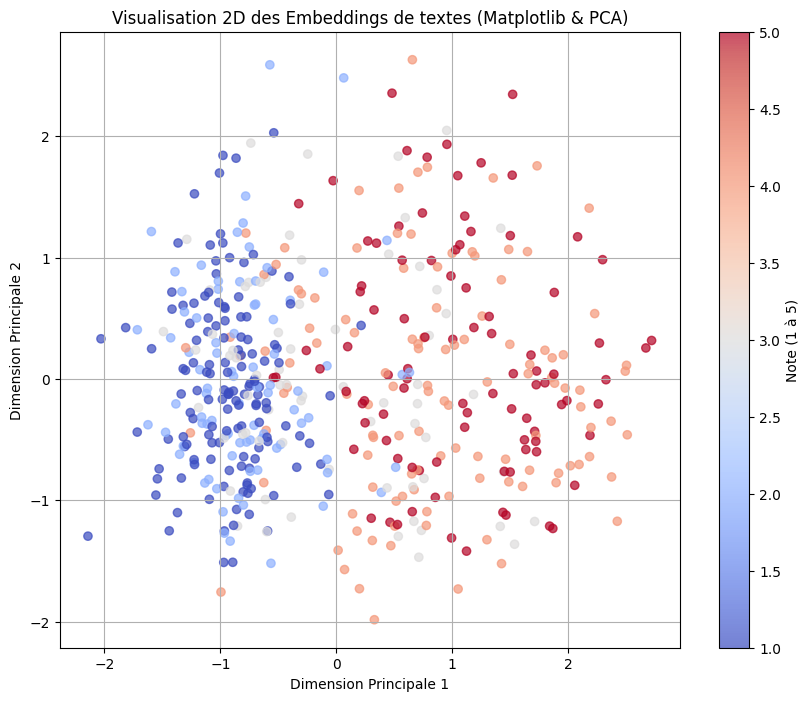

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("--- 4b. Cosine similarity between two reviews ---")
# First and second reviews of the test set
vecteur_1 = X_test_emb[0].reshape(1, -1)
vecteur_2 = X_test_emb[1].reshape(1, -1)

distance = cosine_similarity(vecteur_1, vecteur_2)[0][0]
print(f"Review 1: {X_test.iloc[0][:60]}...")
print(f"Review 2: {X_test.iloc[1][:60]}...")
print(f"-> Cosine similarity between the two reviews: {distance:.4f} (closer to 1 = closer meaning)\n")

print("--- 4c. 2D visualisation of the embeddings (Matplotlib + PCA) ---")
# Reduce the vectors to 2 dimensions to plot them
pca = PCA(n_components=2)
# 500-review sample to keep the plot readable
X_pca = pca.fit_transform(X_test_emb[:500])
y_echantillon = y_test.iloc[:500]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_echantillon, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Note (1 à 5)')
plt.title('Visualisation 2D des Embeddings de textes (Matplotlib & PCA)')
plt.xlabel('Dimension Principale 1')
plt.ylabel('Dimension Principale 2')
plt.grid(True)
plt.show()

## 5. Results Interpretation: Error Analysis
**Methodology:** To understand our Neural Network's limitations, we isolated the "critical errors" (predictions that were off by 3 stars or more compared to the true rating).
**Findings:** By printing the original text of these major failures, we manually identified that the model struggles primarily with:
- **Irony / Sarcasm** (e.g., "Great insurance, they took 3 months to refund me!").
- Highly ambiguous vocabulary where the customer complains about the situation (accident) but praises the agent.

In [ ]:
import pandas as pd
import numpy as np

print("--- 5. Error analysis ---")

# Where the prediction differs from the true rating
erreurs_masque = (y_test_actual != y_pred_dl)
X_test_erreurs = X_test.iloc[erreurs_masque].values
y_true_erreurs = y_test_actual[erreurs_masque]
y_pred_erreurs = y_pred_dl[erreurs_masque]

print(f"The model is wrong on {sum(erreurs_masque)} reviews out of {len(y_test_actual)}.\n")
print("🔍 Examples of critical errors:")

# Critical errors: 3 stars or more between the true rating and the prediction
erreurs_graves = abs(y_true_erreurs - y_pred_erreurs) >= 3

compteur = 0
for i, est_grave in enumerate(erreurs_graves):
    if est_grave:
        print("-" * 50)
        print(f"True rating: {y_true_erreurs[i]} ⭐ | Predicted: {y_pred_erreurs[i]} ⭐")
        print(f"Review: {X_test_erreurs[i][:300]}...")
        compteur += 1
    if compteur == 3: # only show 3 examples
        break

print("-" * 50)
print("💡 Typical causes: irony (e.g. 'Great insurer, they took 3 months to refund me!') or ambiguous vocabulary.")

--- 5. Error analysis ---
The model is wrong on 2221 reviews out of 4814.

🔍 Examples of critical errors:
--------------------------------------------------
True rating: 1 ⭐ | Predicted: 4 ⭐
Review: [review text omitted: personal data]
--------------------------------------------------
True rating: 5 ⭐ | Predicted: 1 ⭐
Review: [review text omitted: personal data]
--------------------------------------------------
True rating: 4 ⭐ | Predicted: 1 ⭐
Review: [review text omitted: personal data]
--------------------------------------------------
💡 Typical causes: irony (e.g. 'Great insurer, they took 3 months to refund me!') or ambiguous vocabulary.


## 6. Semantic Search, Cosine Distance & Word2Vec
**Deep Learning Models for Words:** 1. **Implementation of Cosine Distance:** We mathematically compute the cosine similarity between reviews to prove they share semantic proximity.
2. **Word2Vec Training:** We train a custom Gensim Word2Vec model on our tokenized corpus to find the closest semantic neighbors for industry-specific terms (e.g., "insurance").
3. **Semantic Search Engine:** We created a mock user query ("I had a car accident..."), vectorized it, and used Cosine Distance to retrieve the top 3 most relevant reviews from our 24,000-review database.

In [ ]:
from gensim.models import Word2Vec

print("--- 6a. Word2Vec training ---")
# Tokenisation: one list of words per review
phrases_tokenisees = [str(texte).lower().split() for texte in df['avis_cor_en'].dropna()]

print("Training Word2Vec on the corpus...")
modele_w2v = Word2Vec(sentences=phrases_tokenisees, vector_size=100, window=5, min_count=2, workers=4)

mot_cible = 'insurance'
if mot_cible in modele_w2v.wv:
    similaires = modele_w2v.wv.most_similar(mot_cible, topn=5)
    print(f"\nMost similar words to '{mot_cible}' according to Word2Vec:")
    for mot, score in similaires:
        print(f" - {mot} ({score:.2f})")
else:
    print(f"The word {mot_cible} is not in the vocabulary.")

--- 6a. Word2Vec training ---
Training Word2Vec on the corpus...

Most similar words to 'insurance' according to Word2Vec:
 - insurance, (0.90)
 - insurance. (0.88)
 - insurer (0.79)
 - insurer. (0.73)
 - insurance! (0.72)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print("--- 6b. Semantic search ---")

# 1. Example user query (in English)
requete_utilisateur = "I had a car accident and the customer service is terrible"
print(f"🔎 User query: '{requete_utilisateur}'\n")

# 2. Encode the query
requete_vectorisee = embedder.encode([requete_utilisateur])

# 3. Similarity with the 24,000 reviews
similarites = cosine_similarity(requete_vectorisee, tous_les_embeddings)[0]

# 4. Indices of the 3 most similar reviews
top_3_indices = similarites.argsort()[-3:][::-1]

print("✅ The 3 most relevant reviews in the database:\n")
for position, idx in enumerate(top_3_indices):
    score = similarites[idx]
    note = df['note'].iloc[idx]
    texte = df['avis_cor_en'].iloc[idx]

    print(f"👉 Result #{position + 1} (similarity: {score:.2f} / 1.0)")
    print(f"Rating: {note} ⭐")
    print(f"Review: {texte[:250]}...\n")

--- 6b. Semantic search ---
🔎 User query: 'I had a car accident and the customer service is terrible'

✅ The 3 most relevant reviews in the database:

👉 Result #1 (similarity: 0.73 / 1.0)
Rating: 2.0 ⭐
Review: [review text omitted: personal data]

👉 Result #2 (similarity: 0.68 / 1.0)
Rating: 2.0 ⭐
Review: [review text omitted: personal data]

👉 Result #3 (similarity: 0.68 / 1.0)
Rating: 2.0 ⭐
Review: [review text omitted: personal data]



## 7. Embedding Visualization with TensorBoard
**Visual Validation:**
- **PCA (Matplotlib):** We previously applied Principal Component Analysis to reduce our embeddings to 2D.
- **TensorBoard (3D):** We export a sample of 1,000 vectors and their metadata to TSV format. Using T-SNE in TensorBoard Projector, we can explore in 3D how reviews with different ratings are separated in the embedding space.

In [ ]:
import pandas as pd
import pickle
import numpy as np
import os

# 1. Load the saved data
path_csv = PROCESSED_DIR / 'reviews_clean.csv'
path_pkl = PROCESSED_DIR / 'review_embeddings.pkl'

print("Loading...")
df = pd.read_csv(path_csv)
with open(path_pkl, 'rb') as f:
    embeddings = pickle.load(f)

# 2. 1,000-point sample
n_samples = 1000
vecteurs = np.array(embeddings[:n_samples])
df_sub = df.iloc[:n_samples]

# 3. Vectors in the TSV format expected by the TensorFlow Projector (numbers only)
np.savetxt(PROCESSED_DIR / "vectors.tsv", vecteurs, delimiter="\t", fmt="%.6f")

# 4. Metadata (rating + review excerpt)
with open(PROCESSED_DIR / "metadata.tsv", "w", encoding="utf-8") as f:
    f.write("Label\tText\n")
    for i, row in df_sub.iterrows():
        # remove tabs and line breaks that would break the TSV
        clean_text = str(row['avis_cor_en']).replace('\t', ' ').replace('\n', ' ')[:80]
        f.write(f"{row['note']}\t{clean_text}...\n")

print("✅ Files created! Load them in https://projector.tensorflow.org")

## 7. Conclusion & Architecture Choice for Streamlit
Based on the Error Analysis and Model Comparison conducted in this notebook, here is the architecture selected for production (see `app/app.py`):
- **Score Prediction:** Multilingual BERT (with keyword extraction for Explainability).
- **Topic Detection:** BART-Large-MNLI (Zero-Shot Classification).
- **RAG & Summary:** Llama-3 (8B) deployed locally on Apple Silicon M4. It uses **Cosine Distance** to retrieve relevant reviews and generates more reliable answers, avoiding the hallucinations seen in smaller models like Flan-T5.